In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input,LSTM
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.utils import plot_model



In [2]:
EGG=(45,128)
EG_Feature=(10,)

In [3]:
EGGinputlayer=Input(EGG,name="EGG_Layer")
lstm      =LSTM(45,return_sequences=True)(EGGinputlayer)
lstm1     =LSTM(32)(lstm)



In [4]:
EG_Feature_input=Input(EG_Feature,name="EG_FeatureLayer")
dense1=Dense(45,activation='relu')(EG_Feature_input)
dense2=Dense(32,activation='relu')(dense1)


In [5]:
concatenated_layer=Concatenate() ([lstm1,dense2])
dense=Dense(128,activation='relu',name='denselayer')(concatenated_layer)
output=Dense(64,activation='sigmoid',name='output_layer')(dense)

In [6]:
model =Model(EGGinputlayer,output,name='hybrid Lstm')
model.summary()



Model: "hybrid Lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ EGG_Layer (InputLayer)        │ (None, 45, 128)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ EG_FeatureLayer (InputLayer)  │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 45, 45)            │          31,320 │ EGG_Layer[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 45)                │             495 │ EG_FeatureLayer[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 32)                │           9,984 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │           1,472 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64)                │               0 │ lstm_1[0][0],              │
│                               │                           │                 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ denselayer (Dense)            │ (None, 128)               │           8,320 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_layer (Dense)          │ (None, 64)                │           8,256 │ denselayer[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

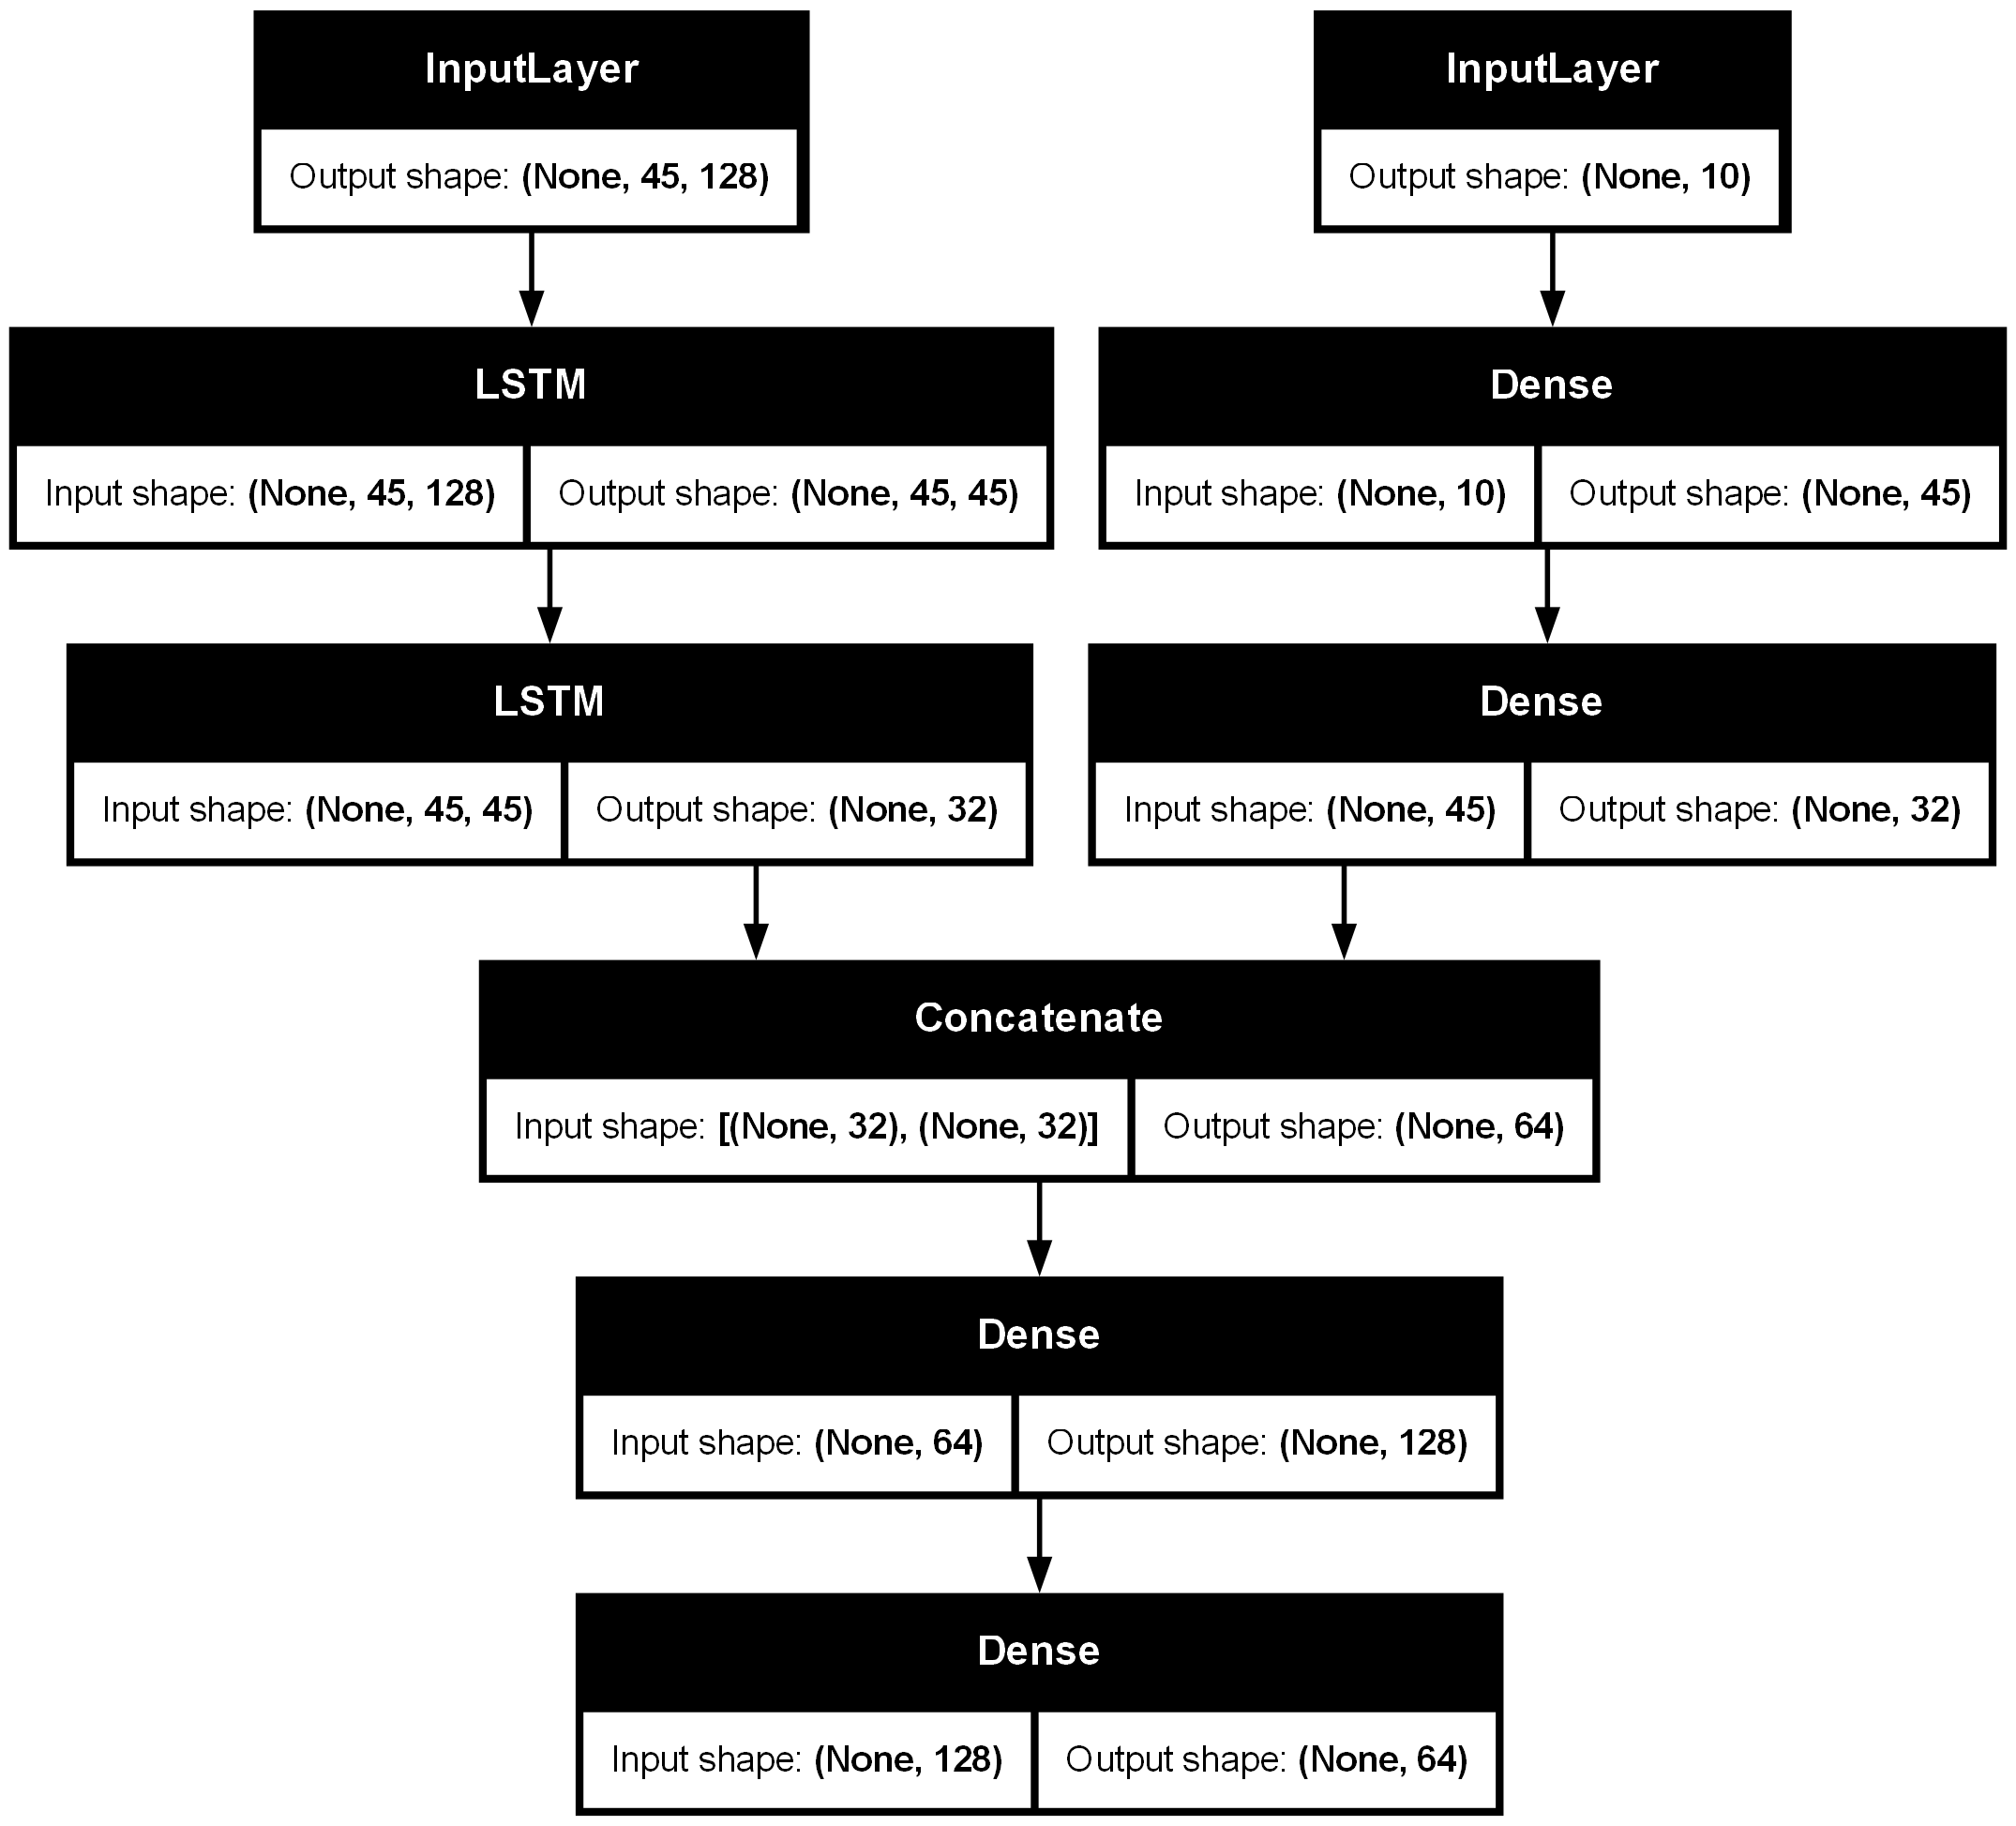

In [7]:

plot_model(model, "model.png", show_shapes=True)